# Planet SDK Match Search POC

This notebook widens the Planet search window around the FloodPlanet `master_index` timestamp to help check whether the reference datetime is offset. It fetches up to 12 full-coverage `PSScene` chips over the FloodPlanet chip bbox for both raw and harmonized modes, then renders one simple tile summary per candidate with the FloodPlanet reference boxplots overlaid as dashed outlines.

Cross-references: [PS README](/workspace/docs/PS/README.md) | [FloodPlanet PS Diagnostics](/workspace/misc/FloodPlanet_PS_diagnostics.ipynb) | [tests/data/readme.md](/workspace/tests/data/readme.md)

In [1]:
# Core imports, fixed working directory, and dependency reporting.
import importlib.metadata
import os
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from IPython.display import Markdown, display
from planet import Session, data_filter, order_request
from rasterio.enums import Resampling
from shapely.geometry import box, mapping, shape


In [2]:
os.chdir("/workspace")
REPO_ROOT = Path("/workspace")
assert Path.cwd().resolve() == REPO_ROOT, f"Expected cwd=/workspace, got {Path.cwd()}"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


In [3]:
# Report the major runtime versions at the top of the notebook.
version_pkg_l = ["planet", "geopandas", "pandas", "rasterio", "matplotlib", "numpy"]
version_rows = []
for pkg_name in version_pkg_l:
    try:
        pkg_version = importlib.metadata.version(pkg_name)
    except importlib.metadata.PackageNotFoundError:
        pkg_version = "not installed"
    version_rows.append({"package": pkg_name, "version": pkg_version})
display(pd.DataFrame(version_rows))


,package,version
0,planet,3.6.0
1,geopandas,1.1.2
2,pandas,3.0.0
3,rasterio,1.4.4
4,matplotlib,3.10.8
5,numpy,2.2.2


## 1. Configuration

Keep the notebook state in a few small dictionaries. This search notebook defaults to a wider `+/-48h` window and now fetches both plain and harmonized variants for each selected candidate scene.

In [4]:
# Project helpers and grouped notebook configuration.
from misc.eval import plot_raster_diagnostics
from fetch.my_secrets import load_secrets

load_secrets(override=False)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 160)

PATH_D = {
    "repo_root": REPO_ROOT,
    "master_index_fp": REPO_ROOT / "tests" / "data" / "FloodPlanet" / "master_index.geojson",
    "floodplanet_source_root": Path("/home/cefect/LS/10_IO/2501_NSFc/zhangFloodPlanet2025"),
}
SEARCH_D = {
    "chip_id": os.environ.get("PLANET_POC_CHIP_ID", os.environ.get("CHIP_ID", "FLO_40_23")),
    "half_window_hours": int(os.environ.get("PLANET_POC_HALF_WINDOW_HOURS", "48")),
    "fetch_max_scenes": int(os.environ.get("PLANET_POC_FETCH_MAX_SCENES", "12")),
    "search_limit": int(os.environ.get("PLANET_POC_SEARCH_LIMIT", "100")),
}
PLANET_D = {
    "mode_l": [
        {"label": "plain", "use_harmonize": False},
        {"label": "harmonized", "use_harmonize": True},
    ],
    "item_type": "PSScene",
    "asset_key": "ortho_analytic_4b_sr",
    "product_bundle": "analytic_sr_udm2",
    "file_format": "COG",
    "harmonize_target_sensor": "Sentinel-2",
    "poll_delay_seconds": 10,
    "poll_max_attempts": 180,
}
RUN_D = {
    "overwrite": False,
}
PLOT_D = {
    "bins": 120,
    "max_points_per_band": 200000,
    "max_preview_side": 700,
    "plot_crs": None,
}
PATH_D["order_root"] = PATH_D["repo_root"] / "misc" / "proof_of_concept" / "planet_sdk_orders_match_search_poc_downloads" / SEARCH_D["chip_id"]
PATH_D["plain_download_dir"] = PATH_D["order_root"] / "plain"
PATH_D["harmonized_download_dir"] = PATH_D["order_root"] / "harmonized"
PATH_D["diagnostic_raster_dir"] = PATH_D["order_root"] / "diagnostic_rasters"
PATH_D["reuse_search_root_l"] = [
    PATH_D["repo_root"] / "misc" / "proof_of_concept" / "planet_sdk_orders_match_search_poc_downloads",
    PATH_D["repo_root"] / "misc" / "proof_of_concept" / "planet_sdk_orders_poc_downloads",
]
PATH_D["plain_download_dir"].mkdir(parents=True, exist_ok=True)
PATH_D["harmonized_download_dir"].mkdir(parents=True, exist_ok=True)
PATH_D["diagnostic_raster_dir"].mkdir(parents=True, exist_ok=True)

assert PATH_D["master_index_fp"].exists(), f"Missing FloodPlanet master index: {PATH_D['master_index_fp']}"
assert PATH_D["floodplanet_source_root"].exists(), f"Missing FloodPlanet source root: {PATH_D['floodplanet_source_root']}"
assert SEARCH_D["half_window_hours"] > 0, f"Expected a positive time window, got {SEARCH_D['half_window_hours']}"
assert SEARCH_D["fetch_max_scenes"] > 0, f"Expected a positive scene cap, got {SEARCH_D['fetch_max_scenes']}"
assert PLANET_D["file_format"] == "COG", f"Notebook is scoped to COG outputs, got {PLANET_D['file_format']}"

print(f"cwd: {Path.cwd()}")
print(f"chip_id: {SEARCH_D['chip_id']}")
print(f"half_window_hours: {SEARCH_D['half_window_hours']}")
print(f"fetch_max_scenes: {SEARCH_D['fetch_max_scenes']}")
print(f"mode_l: {[mode_d['label'] for mode_d in PLANET_D['mode_l']]}")


cwd: /workspace
chip_id: FLO_40_23
half_window_hours: 48
fetch_max_scenes: 12
mode_l: ['plain', 'harmonized']


## 2. FloodPlanet Chip Context

Use the matching FloodPlanet raster to define the search bbox directly, then widen the search window around the `master_index` timestamp.

In [5]:
# Resolve the FloodPlanet chip and use its raster bounds as the Planet search bbox.
master_index_gdf = gpd.read_file(PATH_D["master_index_fp"])
chip_row = master_index_gdf.loc[master_index_gdf["Chip_ID"] == SEARCH_D["chip_id"]].iloc[0]
PATH_D["floodplanet_reference_fp"] = PATH_D["floodplanet_source_root"] / chip_row["Event"] / "PS" / f"{SEARCH_D['chip_id']}.tif"
assert PATH_D["floodplanet_reference_fp"].exists(), f"Missing FloodPlanet raster: {PATH_D['floodplanet_reference_fp']}"

reference_dt = pd.Timestamp(chip_row["datetime"])
SEARCH_D["reference_dt"] = reference_dt.tz_localize("UTC") if reference_dt.tzinfo is None else reference_dt.tz_convert("UTC")
SEARCH_D["start_dt"] = SEARCH_D["reference_dt"] - pd.Timedelta(hours=SEARCH_D["half_window_hours"])
SEARCH_D["end_dt"] = SEARCH_D["reference_dt"] + pd.Timedelta(hours=SEARCH_D["half_window_hours"])

with rasterio.open(PATH_D["floodplanet_reference_fp"]) as ds:
    SEARCH_D["bbox"] = ds.bounds
    SEARCH_D["bbox_geom"] = box(*ds.bounds)
    SEARCH_D["bbox_geojson"] = mapping(SEARCH_D["bbox_geom"])
    SEARCH_D["floodplanet_crs"] = str(ds.crs)
    SEARCH_D["floodplanet_shape"] = (ds.height, ds.width, ds.count)

display(pd.DataFrame([{
    "chip_id": SEARCH_D["chip_id"],
    "event": chip_row["Event"],
    "master_index_datetime_utc": SEARCH_D["reference_dt"].isoformat(),
    "search_start_utc": SEARCH_D["start_dt"].isoformat(),
    "search_end_utc": SEARCH_D["end_dt"].isoformat(),
    "floodplanet_raster": str(PATH_D["floodplanet_reference_fp"]),
    "floodplanet_crs": SEARCH_D["floodplanet_crs"],
    "floodplanet_shape": SEARCH_D["floodplanet_shape"],
    "bbox": tuple(round(val, 8) for val in SEARCH_D["bbox"]),
}]))


,chip_id,event,master_index_datetime_utc,search_start_utc,search_end_utc,floodplanet_raster,floodplanet_crs,floodplanet_shape,bbox
0,FLO_40_23,US-Carolina,2018-09-19T00:00:00+00:00,2018-09-17T00:00:00+00:00,2018-09-21T00:00:00+00:00,/home/cefect/LS/10_IO/2501_NSFc/zhangFloodPlanet2025/US-Carolina/PS/FLO_40_23.tif,EPSG:4326,"(1024, 1024, 4)","(-78.98314454, 34.54954569, -78.95083134, 34.58185889)"


## 3. Query Full-Coverage Planet Scenes

Search the Planet Data API over the FloodPlanet chip bbox, keep only scenes with the SR asset and full bbox coverage, then cap the fetch set at 12 scenes by time proximity.

In [6]:
def _item_time(item: dict) -> pd.Timestamp:
    """Return the acquisition time for one Planet item as UTC."""
    acquired = pd.Timestamp(item["properties"]["acquired"])
    return acquired.tz_localize("UTC") if acquired.tzinfo is None else acquired.tz_convert("UTC")


async def _query_matching_scenes() -> dict:
    """Search Planet scenes and keep the full-coverage SR candidates nearest in time."""
    async with Session() as sess:
        data_client = sess.client("data")
        search_filter = data_filter.and_filter([
            data_filter.permission_filter(),
            data_filter.date_range_filter("acquired", gte=SEARCH_D["start_dt"].to_pydatetime(), lte=SEARCH_D["end_dt"].to_pydatetime()),
            data_filter.geometry_filter(SEARCH_D["bbox_geojson"]),
        ])

        items = []
        async for item in data_client.search([PLANET_D["item_type"]], search_filter, sort="acquired asc", limit=SEARCH_D["search_limit"]):
            items.append(item)
        assert items, f"No {PLANET_D['item_type']} scenes were returned for {SEARCH_D['chip_id']}"

        asset_keys_by_item = {}
        for item in items:
            assets = await data_client.list_item_assets(PLANET_D["item_type"], item["id"])
            asset_keys_by_item[item["id"]] = sorted(assets.keys())

    rows = []
    for item in items:
        acquired = _item_time(item)
        item_geom = shape(item["geometry"])
        intersection = item_geom.intersection(SEARCH_D["bbox_geom"])
        coverage_ratio = float(intersection.area / SEARCH_D["bbox_geom"].area) if SEARCH_D["bbox_geom"].area > 0 else np.nan
        rows.append({
            "item_id": item["id"],
            "acquired_utc": acquired.isoformat(),
            "time_delta_h": round(abs((acquired - SEARCH_D["reference_dt"]).total_seconds()) / 3600.0, 3),
            "instrument": item.get("properties", {}).get("instrument") or ",".join(item.get("properties", {}).get("instruments") or []),
            "cloud_cover": item.get("properties", {}).get("cloud_cover"),
            "clear_percent": item.get("properties", {}).get("clear_percent"),
            "bbox_coverage_ratio": round(coverage_ratio, 6),
            "covers_bbox": item_geom.buffer(1e-12).covers(SEARCH_D["bbox_geom"]),
            "has_target_asset": PLANET_D["asset_key"] in asset_keys_by_item[item["id"]],
        })

    query_df = pd.DataFrame(rows).sort_values(["time_delta_h", "item_id"]).reset_index(drop=True)
    eligible_df = query_df.loc[query_df["covers_bbox"] & query_df["has_target_asset"]].copy().reset_index(drop=True)
    assert not eligible_df.empty, f"No full-coverage scenes exposed {PLANET_D['asset_key']} in the widened window."
    selected_df = eligible_df.head(SEARCH_D["fetch_max_scenes"]).copy().reset_index(drop=True)
    selected_df.insert(0, "fetch_rank", np.arange(1, len(selected_df) + 1))

    return {
        "query_df": query_df,
        "eligible_df": eligible_df,
        "selected_df": selected_df,
        "asset_keys_by_item": asset_keys_by_item,
    }


In [7]:
query_result = await _query_matching_scenes()

display(Markdown("### 3A. All queried scenes"))
display(query_result["query_df"])

display(Markdown("### 3B. Full-coverage SR candidates selected for fetch"))
display(query_result["selected_df"])

print(f"Selected {len(query_result['selected_df'])} scene(s) for fetch.")


### 3A. All queried scenes

,item_id,acquired_utc,time_delta_h,instrument,cloud_cover,clear_percent,bbox_coverage_ratio,covers_bbox,has_target_asset
0,20180918_152955_0f35,2018-09-18T15:29:55.692972+00:00,8.501,PS2,0.02,98,0.060083,False,True
1,20180918_152956_0f35,2018-09-18T15:29:56.742597+00:00,8.501,PS2,0.05,95,1.000000,True,True
2,20180918_152115_104b,2018-09-18T15:21:15.322711+00:00,8.646,PS2,0.13,87,0.197651,False,True
3,20180919_152007_100d,2018-09-19T15:20:07.483168+00:00,15.335,PS2,0.03,97,1.000000,True,True
4,20180919_153017_1015,2018-09-19T15:30:17.813826+00:00,15.505,PS2,0.02,98,0.374087,False,True
5,20180919_153018_1015,2018-09-19T15:30:18.859256+00:00,15.505,PS2,0.02,98,0.864716,False,True
6,20180917_153027_0f42,2018-09-17T15:30:27.989271+00:00,32.492,PS2,1.00,0,0.785517,False,True
7,20180917_153026_0f42,2018-09-17T15:30:26.943317+00:00,32.493,PS2,0.99,0,0.428999,False,True
8,20180920_153030_1004,2018-09-20T15:30:30.396623+00:00,39.508,PS2,0.25,62,1.000000,True,True
9,20180920_153031_1004,2018-09-20T15:30:31.443626+00:00,39.509,PS2,0.25,60,0.059419,False,True


### 3B. Full-coverage SR candidates selected for fetch

,fetch_rank,item_id,acquired_utc,time_delta_h,instrument,cloud_cover,clear_percent,bbox_coverage_ratio,covers_bbox,has_target_asset
0,1,20180918_152956_0f35,2018-09-18T15:29:56.742597+00:00,8.501,PS2,0.05,95,1.0,True,True
1,2,20180919_152007_100d,2018-09-19T15:20:07.483168+00:00,15.335,PS2,0.03,97,1.0,True,True
2,3,20180920_153030_1004,2018-09-20T15:30:30.396623+00:00,39.508,PS2,0.25,62,1.0,True,True


Selected 3 scene(s) for fetch.


## 4. FloodPlanet Reference Tile Summary

Plot the FloodPlanet reference first, then fetch and plot each Planet candidate with the same simple diagnostics helper.

In [8]:
def _download_dir(use_harmonize: bool) -> Path:
    """Return the mode-specific download directory."""
    return PATH_D["harmonized_download_dir"] if use_harmonize else PATH_D["plain_download_dir"]


def _mode_label(use_harmonize: bool) -> str:
    """Return the fetch mode label."""
    return "harmonized" if use_harmonize else "plain"


def _existing_raster_fp(item_id: str, use_harmonize: bool) -> Path | None:
    """Return one matching local SR raster for the item when present under any reuse root."""
    name_token = "AnalyticMS_SR_harmonized" if use_harmonize else "AnalyticMS_SR_clip"
    match_l = []
    for search_root in PATH_D["reuse_search_root_l"]:
        if not search_root.exists():
            continue
        for path in search_root.rglob(f"*{item_id}*{name_token}*.tif"):
            path = Path(path).resolve()
            if "diagnostic_rasters" in path.parts or path.stem.endswith("_diagmask"):
                continue
            match_l.append(path)
    match_l = sorted(set(match_l))
    return match_l[0] if match_l else None


def _band_label_l(ds) -> list[str]:
    """Return normalized band labels for one raster."""
    if ds.descriptions and any(ds.descriptions):
        return [str(label or f"Band {i}") for i, label in enumerate(ds.descriptions, start=1)]
    if ds.count >= 4:
        return ["blue", "green", "red", "nir"][: ds.count]
    return [f"Band {i}" for i in range(1, ds.count + 1)]


def _prepared_diagnostic_fp(raster_fp: Path) -> Path:
    """Return the filepath for the mask-normalized diagnostics raster."""
    return PATH_D["diagnostic_raster_dir"] / f"{raster_fp.stem}_diagmask.tif"


def _prepare_diagnostic_raster(raster_fp: Path) -> Path:
    """Write a temporary raster with one shared dataset mask for diagnostics plotting."""
    out_fp = _prepared_diagnostic_fp(raster_fp)
    if out_fp.exists() and not RUN_D["overwrite"]:
        return out_fp

    with rasterio.open(raster_fp) as src:
        valid_mask_l = []
        for band_idx, band_label in enumerate(_band_label_l(src), start=1):
            if band_label.lower() in {"fill_mask", "state_1km", "masked"}:
                continue
            valid_mask_l.append(src.read_masks(band_idx) > 0)
        assert valid_mask_l, f"No plottable bands found for diagnostics prep: {raster_fp}"
        valid_bx = np.logical_and.reduce(valid_mask_l)

        profile = src.profile.copy()
        profile.update(driver="GTiff")
        with rasterio.open(out_fp, "w", **profile) as dst:
            for band_idx in range(1, src.count + 1):
                dst.write(src.read(band_idx), band_idx)
                if src.descriptions:
                    dst.set_band_description(band_idx, src.descriptions[band_idx - 1])
            dst.write_mask(valid_bx.astype("uint8") * 255)
            dst.update_tags(**src.tags())
    return out_fp


def _sample_band_values(raster_fp: Path) -> dict[str, np.ndarray]:
    """Read masked band samples once for overlay boxplots."""
    diag_fp = _prepare_diagnostic_raster(raster_fp)
    sample_d = {}
    rng = np.random.default_rng(42)
    with rasterio.open(diag_fp) as ds:
        for band_idx, band_label in enumerate(_band_label_l(ds), start=1):
            values = ds.read(band_idx, masked=True).compressed().astype("float32", copy=False)
            if values.size == 0:
                continue
            if values.size > PLOT_D["max_points_per_band"]:
                values = rng.choice(values, size=PLOT_D["max_points_per_band"], replace=False)
            sample_d[band_label] = values
    return sample_d


def _overlay_reference_boxplots(ax_box, band_label_l: list[str], reference_sample_d: dict[str, np.ndarray]):
    """Overlay FloodPlanet reference boxplots as dashed outlines on the boxplot axis."""
    reference_data = [reference_sample_d[band_label] for band_label in band_label_l if band_label in reference_sample_d]
    positions = [idx for idx, band_label in enumerate(band_label_l, start=1) if band_label in reference_sample_d]
    assert len(reference_data) == len(positions), "Reference overlay positions must match the prepared samples."
    if not reference_data:
        return

    base_patch_l = list(ax_box.patches)
    color_l = [patch.get_edgecolor() for patch in base_patch_l[: len(positions)]]
    ref_bp = ax_box.boxplot(
        reference_data,
        vert=False,
        positions=positions,
        widths=0.35,
        showfliers=False,
        patch_artist=True,
        manage_ticks=False,
    )
    for box_idx, color in enumerate(color_l):
        ref_bp["boxes"][box_idx].set(facecolor="none", edgecolor=color, linestyle="--", linewidth=1.5)
        ref_bp["medians"][box_idx].set(color=color, linestyle="--", linewidth=1.2)
        ref_bp["whiskers"][2 * box_idx].set(color=color, linestyle="--", linewidth=1.0)
        ref_bp["whiskers"][2 * box_idx + 1].set(color=color, linestyle="--", linewidth=1.0)
        ref_bp["caps"][2 * box_idx].set(color=color, linestyle="--", linewidth=1.0)
        ref_bp["caps"][2 * box_idx + 1].set(color=color, linestyle="--", linewidth=1.0)
    ax_box.plot([], [], color="#444444", linestyle="--", linewidth=1.5, label="FloodPlanet reference")
    ax_box.legend(loc="best")


def _plot_tile_summary(raster_fp: Path, tile_label: str, title_prefix: str, reference_fp: Path | None = None):
    """Render one diagnostics plot and optionally overlay the FloodPlanet reference boxplots."""
    diag_fp = _prepare_diagnostic_raster(raster_fp)
    diag_result = plot_raster_diagnostics(
        raster_fp=diag_fp,
        sensorID="PS",
        tile_id=tile_label,
        title=f"{title_prefix}: {tile_label}",
        bins=PLOT_D["bins"],
        max_points_per_band=PLOT_D["max_points_per_band"],
        max_preview_side=PLOT_D["max_preview_side"],
        plot_crs=PLOT_D["plot_crs"],
    )
    fig, axes = diag_result if isinstance(diag_result, tuple) else (diag_result, None)
    if axes is not None and reference_fp is not None:
        ax_box = axes[0]
        with rasterio.open(diag_fp) as ds:
            band_label_l = _band_label_l(ds)
        _overlay_reference_boxplots(ax_box, band_label_l, _sample_band_values(reference_fp))
    plt.show()
    return fig


async def _fetch_one_item(item_id: str, use_harmonize: bool) -> tuple[str, str]:
    """Fetch one scene order for the requested mode."""
    mode_label = _mode_label(use_harmonize)
    download_dir = _download_dir(use_harmonize)
    async with Session() as sess:
        orders_client = sess.client("orders")
        tools = [
            order_request.clip_tool(aoi=SEARCH_D["bbox_geojson"]),
            order_request.file_format_tool(PLANET_D["file_format"]),
        ]
        if use_harmonize:
            tools.append(order_request.harmonize_tool(PLANET_D["harmonize_target_sensor"]))
        request = order_request.build_request(
            name=f"{SEARCH_D['chip_id'].lower()}_{mode_label}_{item_id}",
            products=[order_request.product(item_ids=[item_id], product_bundle=PLANET_D["product_bundle"], item_type=PLANET_D["item_type"])],
            tools=tools,
        )
        print(f"Submitting {mode_label} order for {item_id}.")
        order = await orders_client.create_order(request)
        status = await orders_client.wait(order["id"], delay=PLANET_D["poll_delay_seconds"], max_attempts=PLANET_D["poll_max_attempts"])
        _ = await orders_client.download_order(order["id"], download_dir, overwrite=RUN_D["overwrite"], progress_bar=False)
        print(f"{mode_label.title()} order {order['id']} for {item_id} finished with state={status}.")
    return order["id"], status


async def _fetch_selected_items(query_result: dict, use_harmonize: bool) -> dict:
    """Fetch the selected scenes for one mode, reusing any local rasters."""
    selected_df = query_result["selected_df"].copy()
    mode_label = _mode_label(use_harmonize)
    order_id_l = []
    status_l = []
    fetch_rows = []

    for _, row in selected_df.iterrows():
        raster_fp = _existing_raster_fp(row["item_id"], use_harmonize=use_harmonize)
        reused_local = raster_fp is not None
        if raster_fp is None:
            order_id, status = await _fetch_one_item(row["item_id"], use_harmonize=use_harmonize)
            order_id_l.append(order_id)
            status_l.append(status)
            raster_fp = _existing_raster_fp(row["item_id"], use_harmonize=use_harmonize)
        assert raster_fp is not None, f"Missing downloaded raster for {row['item_id']} ({mode_label})"
        fetch_rows.append({
            "fetch_rank": row["fetch_rank"],
            "item_id": row["item_id"],
            "acquired_utc": row["acquired_utc"],
            "time_delta_h": row["time_delta_h"],
            "instrument": row["instrument"],
            "cloud_cover": row["cloud_cover"],
            "bbox_coverage_ratio": row["bbox_coverage_ratio"],
            "mode": mode_label,
            "raster_fp": raster_fp,
            "reused_local": reused_local,
        })

    return {
        "mode_label": mode_label,
        "status": "reused_local" if not status_l else ",".join(status_l),
        "order_ids": order_id_l,
        "download_dir": _download_dir(use_harmonize),
        "fetch_df": pd.DataFrame(fetch_rows),
    }


### 4A. FloodPlanet reference tile summary

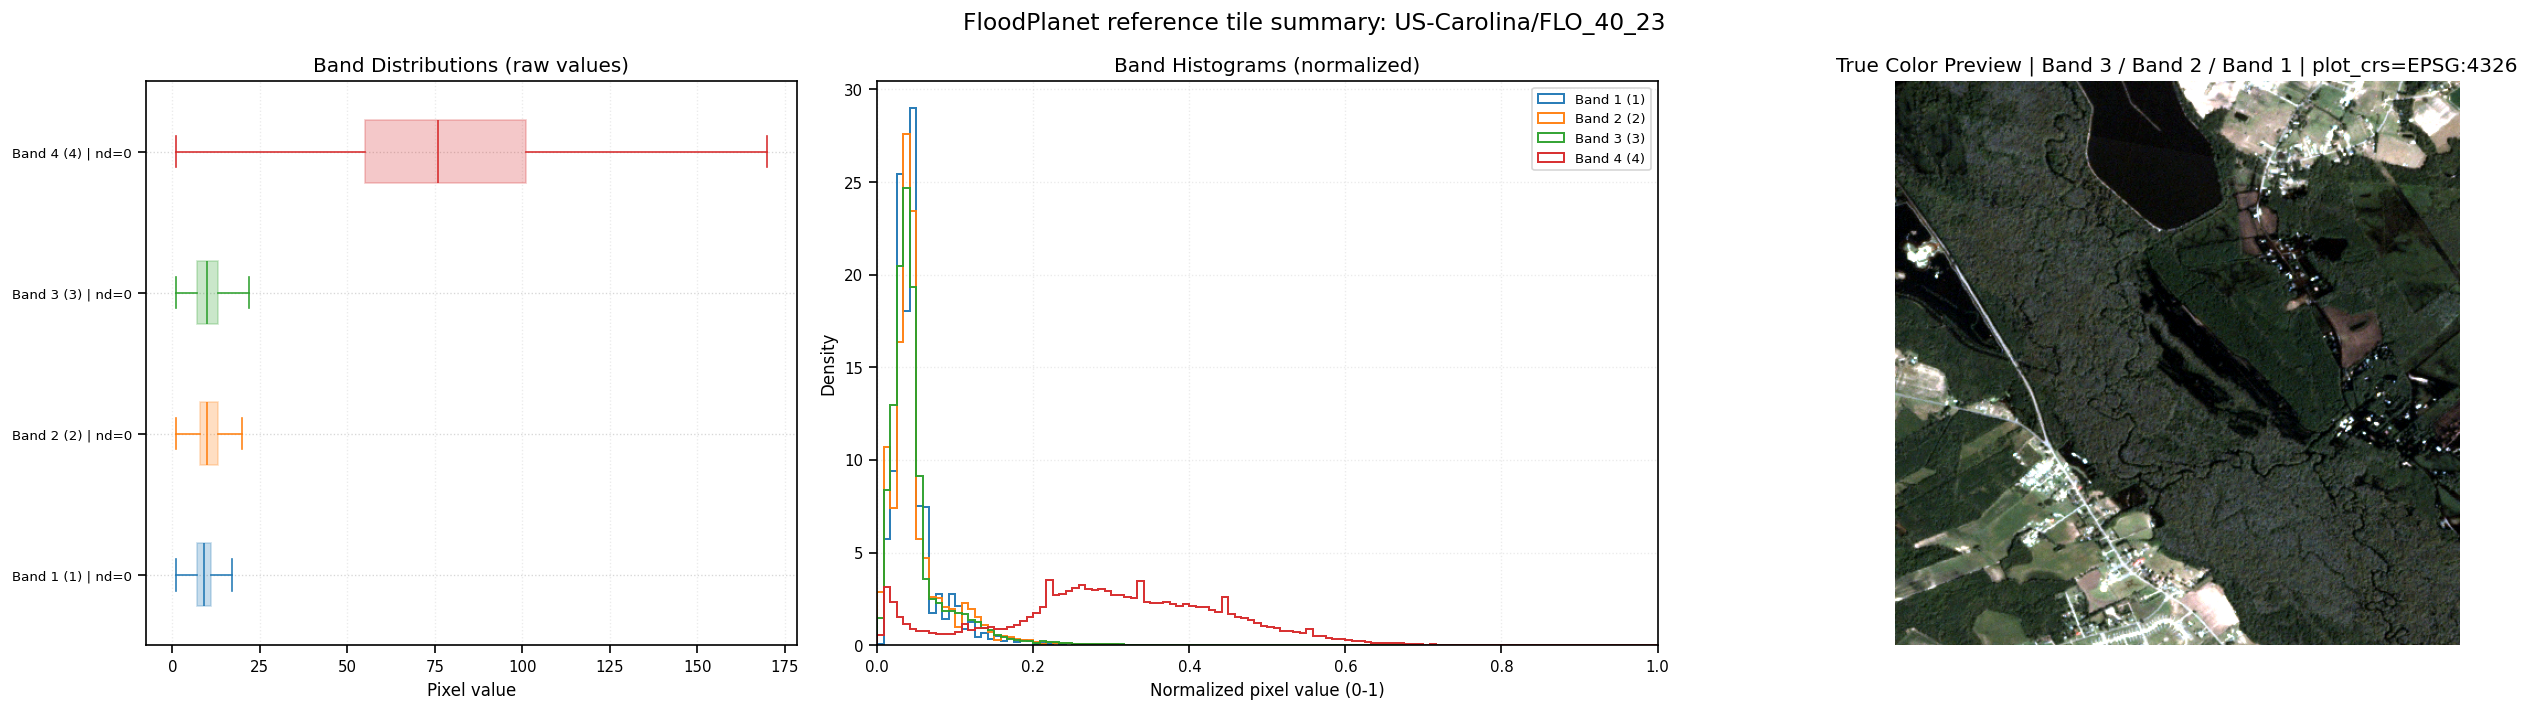

In [9]:
display(Markdown("### 4A. FloodPlanet reference tile summary"))
_ = _plot_tile_summary(
    PATH_D["floodplanet_reference_fp"],
    tile_label=f"{chip_row['Event']}/{chip_row['Chip_ID']}",
    title_prefix="FloodPlanet reference tile summary",
)


## 5. Fetch And Plot Candidate Scenes

Fetch the selected scenes for both raw and harmonized modes, then render one simple tile summary per candidate with the FloodPlanet reference boxplots overlaid as dashed outlines.

Submitting plain order for 20180919_152007_100d.


Plain order 5e0c5957-1d61-426c-a579-52f3efe58cdc for 20180919_152007_100d finished with state=success.
Submitting plain order for 20180920_153030_1004.


Plain order 6772e6b6-0608-476c-b253-39a094bf1cc7 for 20180920_153030_1004 finished with state=success.


### 5A. Fetch summary

,mode,status,order_ids,download_dir,fetched_scene_count
0,plain,"success,success","5e0c5957-1d61-426c-a579-52f3efe58cdc, 6772e6b6-0608-476c-b253-39a094bf1cc7",misc/proof_of_concept/planet_sdk_orders_match_search_poc_downloads/FLO_40_23/plain,3
1,harmonized,reused_local,NaN,misc/proof_of_concept/planet_sdk_orders_match_search_poc_downloads/FLO_40_23/harmonized,3


### 5B. Candidate raster summary

,fetch_rank,item_id,acquired_utc,time_delta_h,instrument,cloud_cover,bbox_coverage_ratio,mode,raster_fp,reused_local
0,1,20180918_152956_0f35,2018-09-18T15:29:56.742597+00:00,8.501,PS2,0.05,1.0,plain,/workspace/misc/proof_of_concept/planet_sdk_orders_poc_downloads/FLO_40_23/plain/8de044db-16b6-40b9-ab35-c89f9e79ec96/PSScene/20180918_152956_0f35_3B_Analyt...,True
1,2,20180919_152007_100d,2018-09-19T15:20:07.483168+00:00,15.335,PS2,0.03,1.0,plain,/workspace/misc/proof_of_concept/planet_sdk_orders_match_search_poc_downloads/FLO_40_23/plain/5e0c5957-1d61-426c-a579-52f3efe58cdc/PSScene/20180919_152007_1...,False
2,3,20180920_153030_1004,2018-09-20T15:30:30.396623+00:00,39.508,PS2,0.25,1.0,plain,/workspace/misc/proof_of_concept/planet_sdk_orders_match_search_poc_downloads/FLO_40_23/plain/6772e6b6-0608-476c-b253-39a094bf1cc7/PSScene/20180920_153030_1...,False
3,1,20180918_152956_0f35,2018-09-18T15:29:56.742597+00:00,8.501,PS2,0.05,1.0,harmonized,/workspace/misc/proof_of_concept/planet_sdk_orders_match_search_poc_downloads/FLO_40_23/harmonized/7649f8ea-b17d-4382-b3e7-3f5fefb03773/PSScene/20180918_152...,True
4,2,20180919_152007_100d,2018-09-19T15:20:07.483168+00:00,15.335,PS2,0.03,1.0,harmonized,/workspace/misc/proof_of_concept/planet_sdk_orders_match_search_poc_downloads/FLO_40_23/harmonized/7649f8ea-b17d-4382-b3e7-3f5fefb03773/PSScene/20180919_152...,True
5,3,20180920_153030_1004,2018-09-20T15:30:30.396623+00:00,39.508,PS2,0.25,1.0,harmonized,/workspace/misc/proof_of_concept/planet_sdk_orders_match_search_poc_downloads/FLO_40_23/harmonized/7649f8ea-b17d-4382-b3e7-3f5fefb03773/PSScene/20180920_153...,True


### 5C. Plain candidate plots

#### plain | 1 | 20180918_152956_0f35

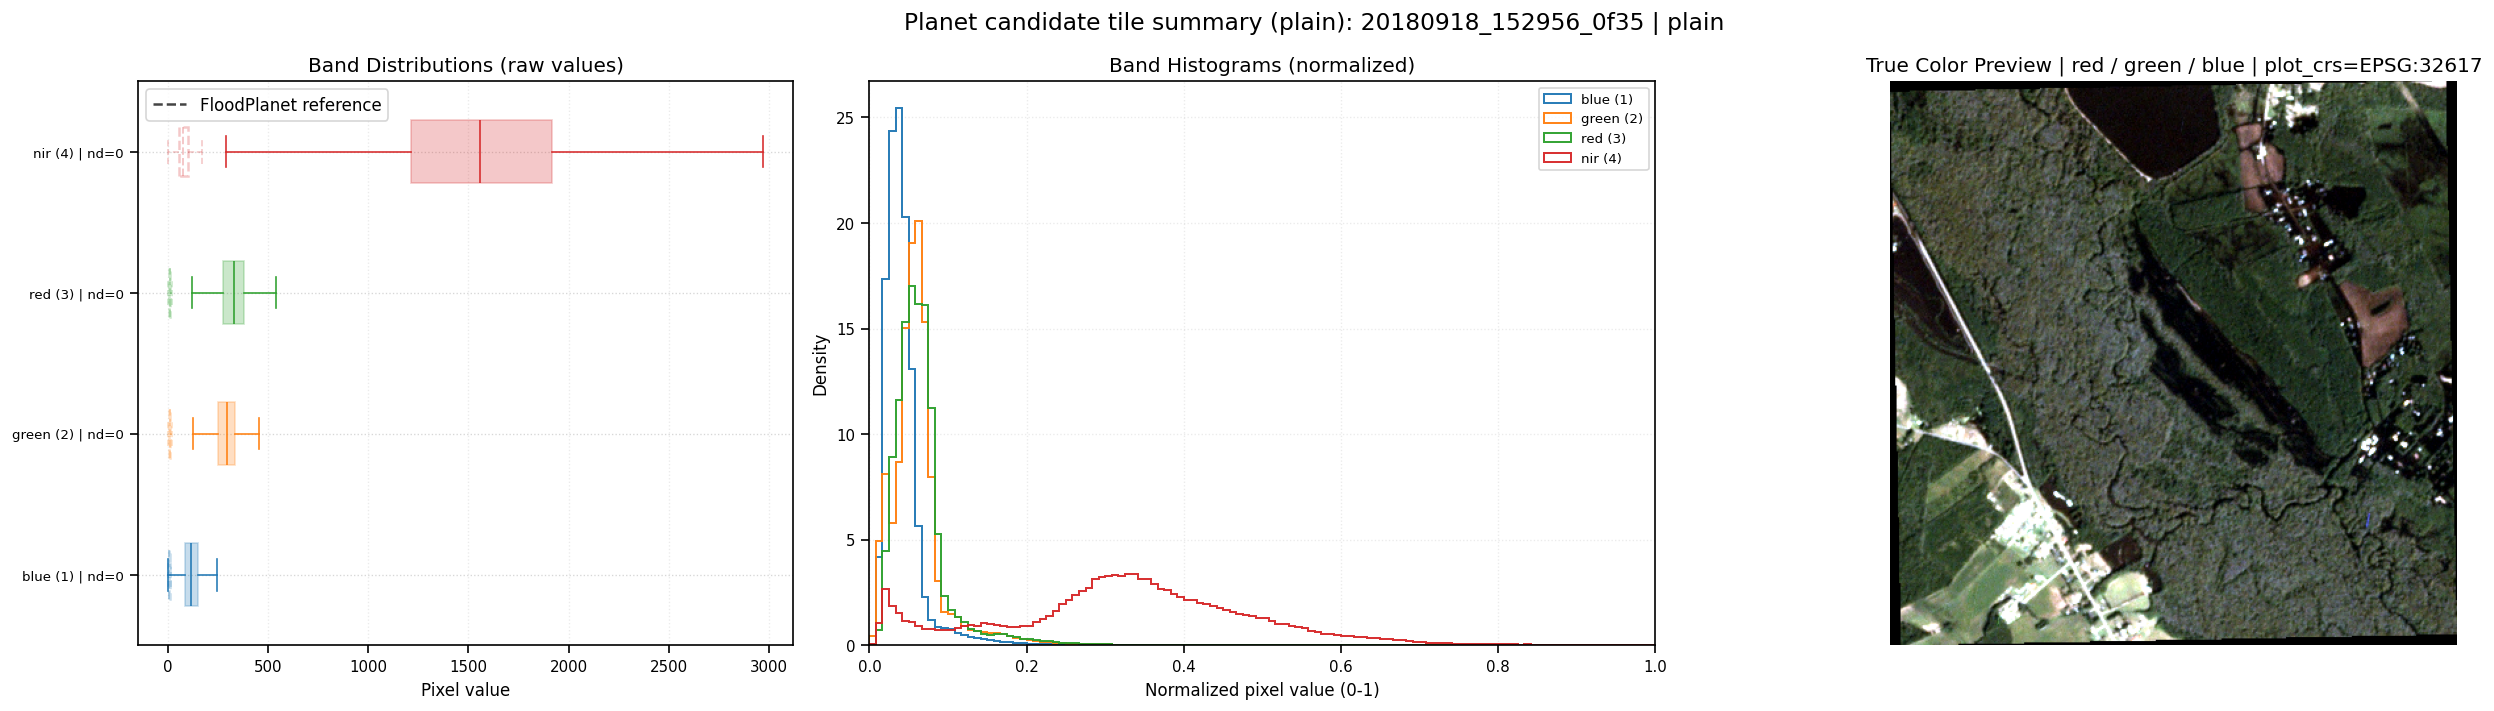

#### plain | 2 | 20180919_152007_100d

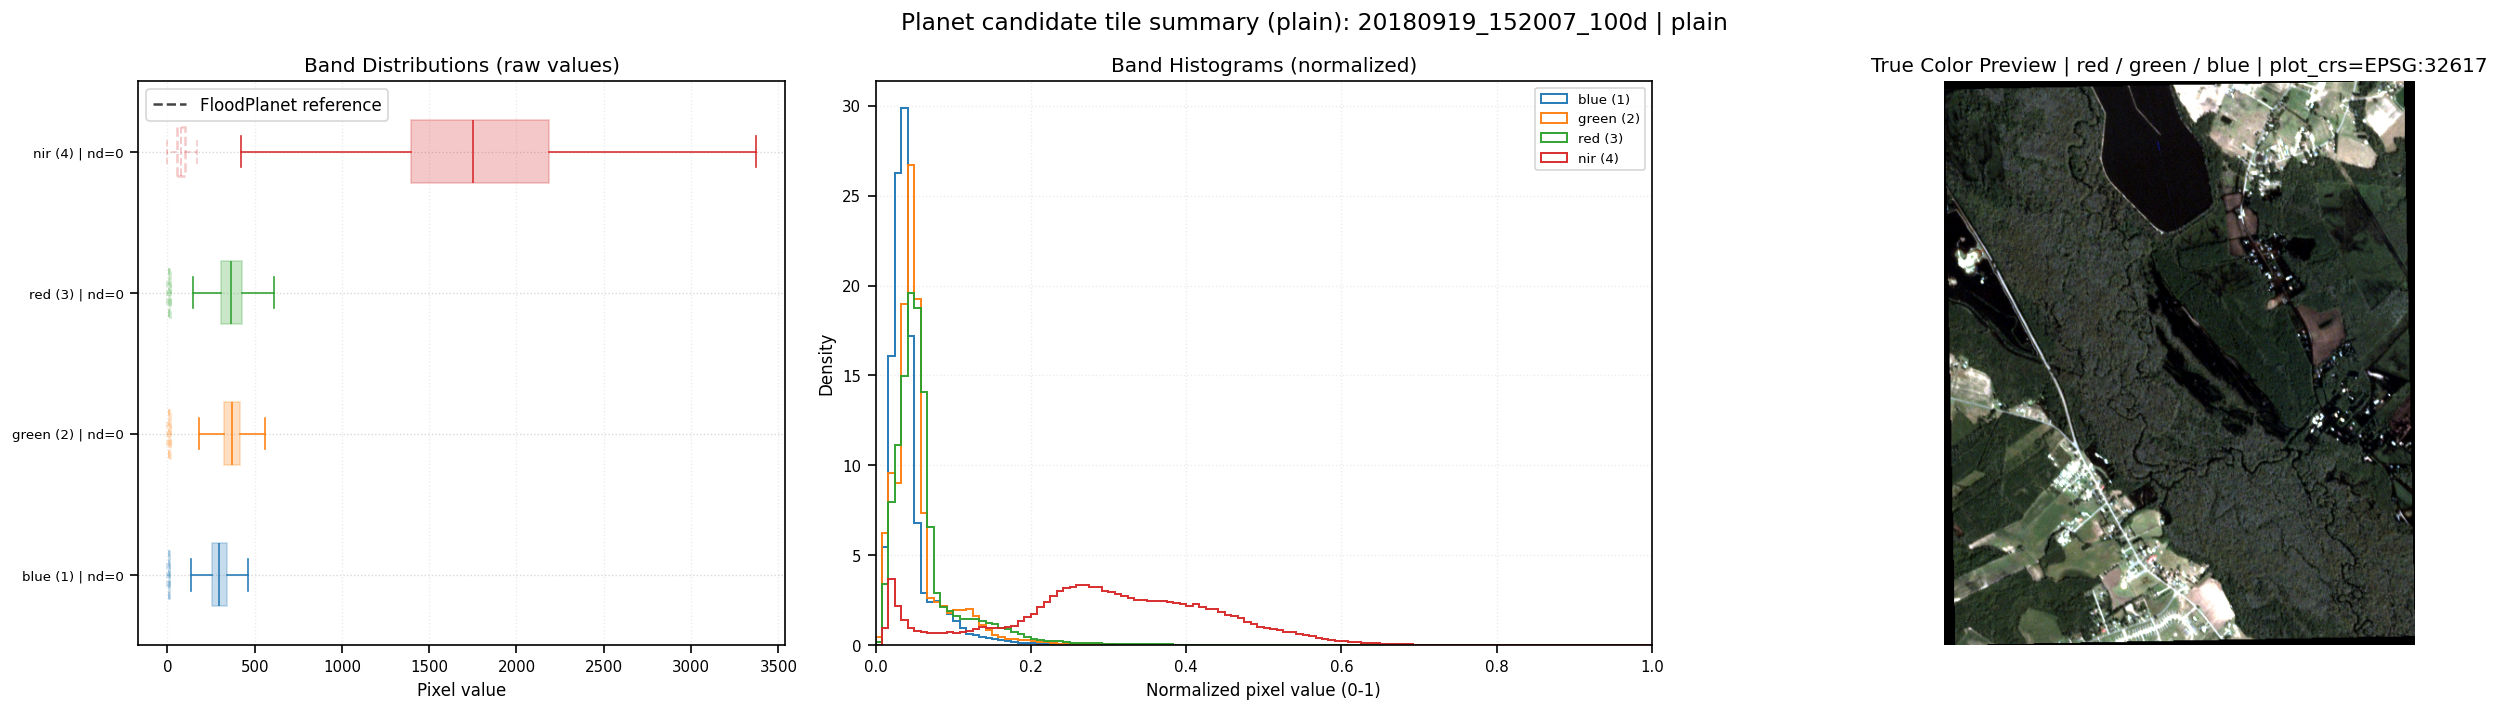

#### plain | 3 | 20180920_153030_1004

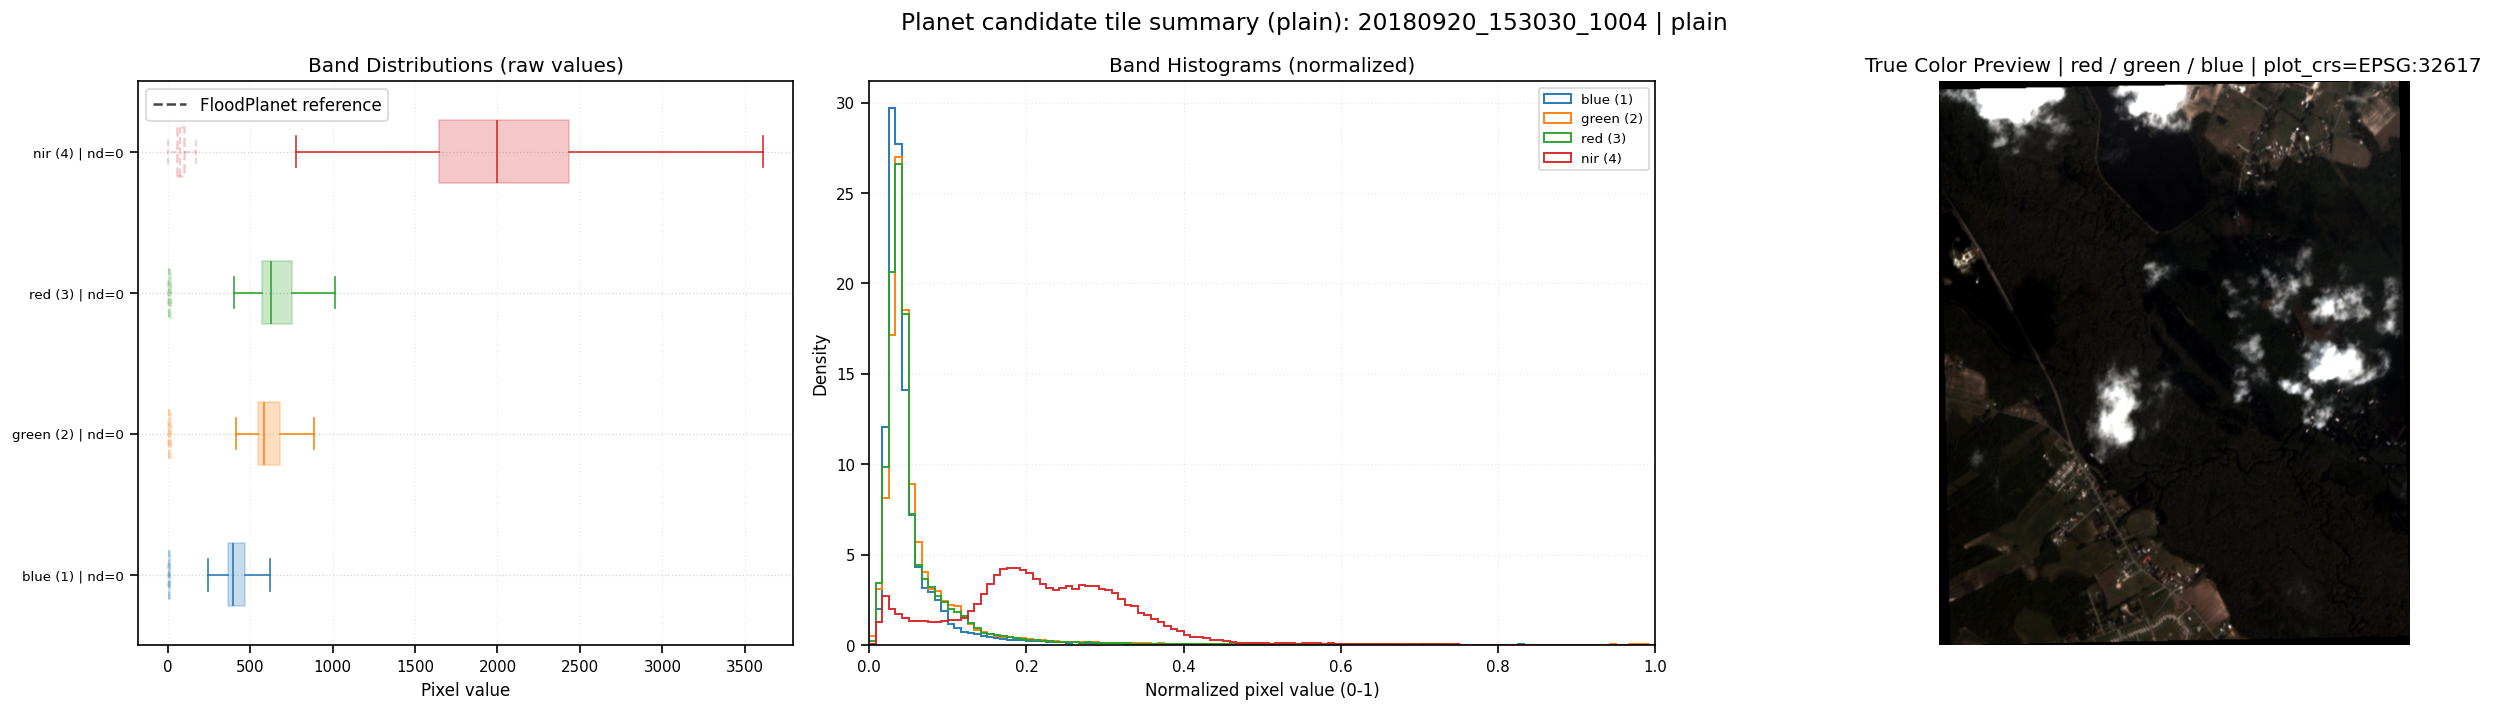

### 5C. Harmonized candidate plots

#### harmonized | 1 | 20180918_152956_0f35

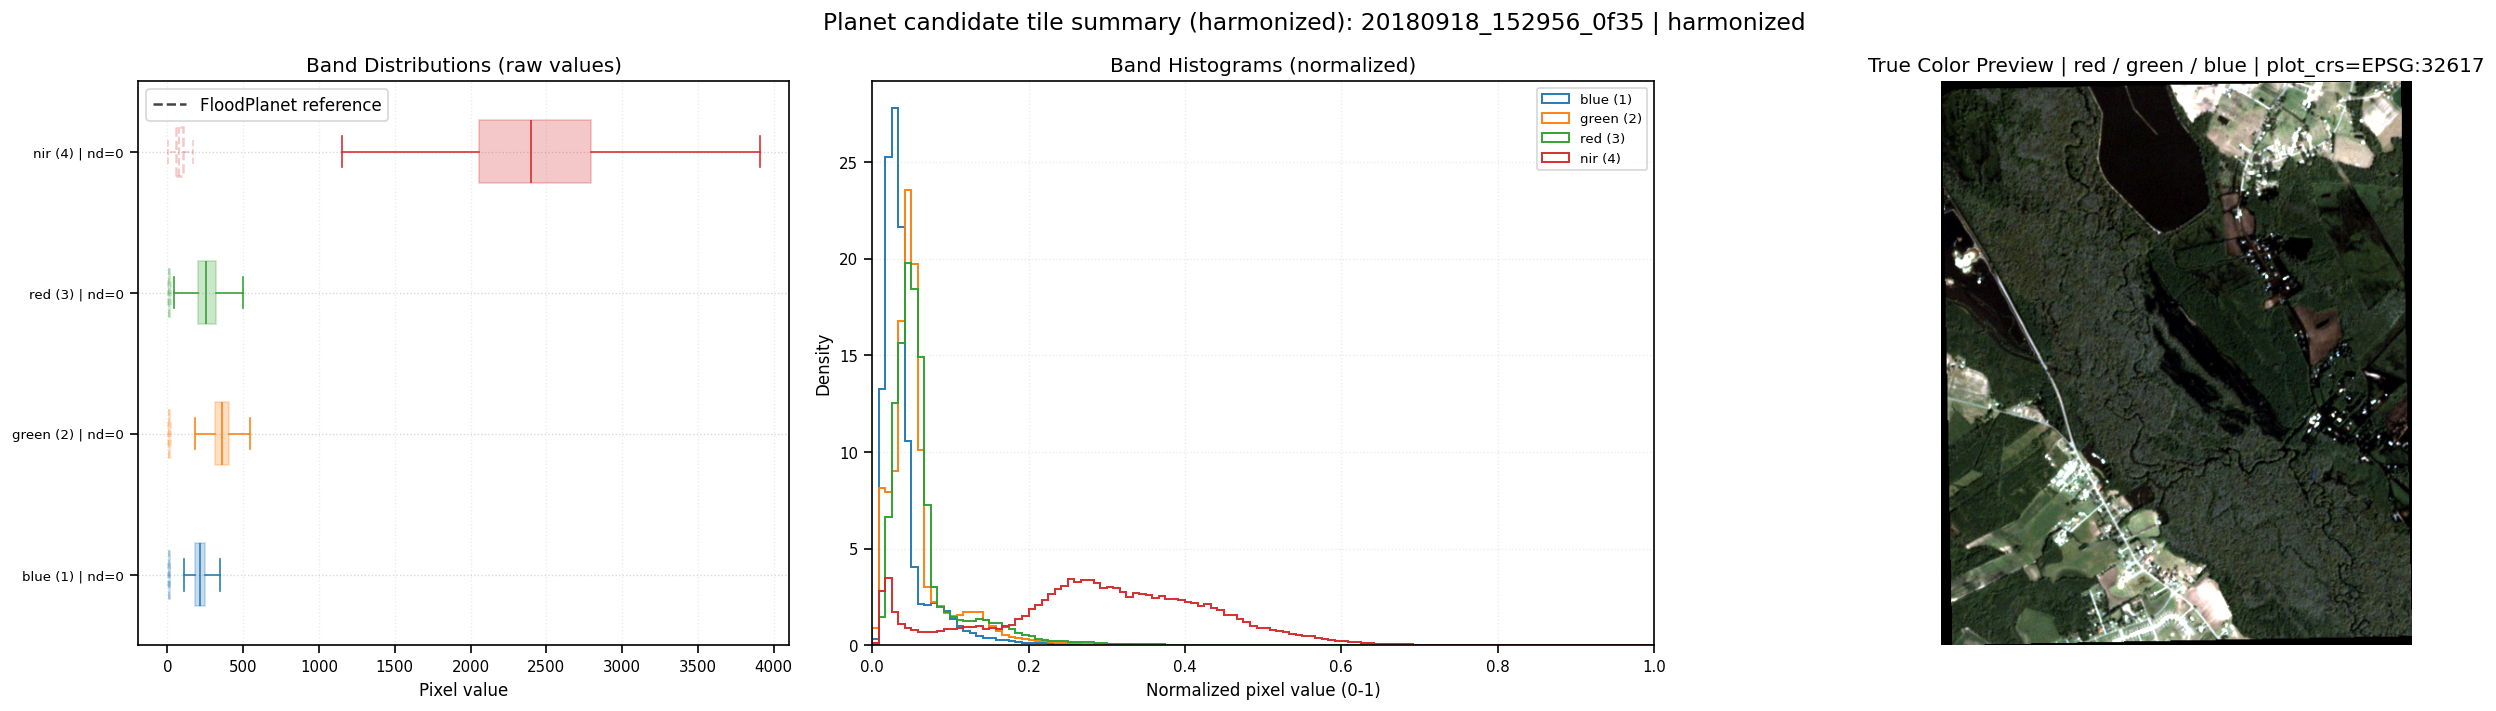

#### harmonized | 2 | 20180919_152007_100d

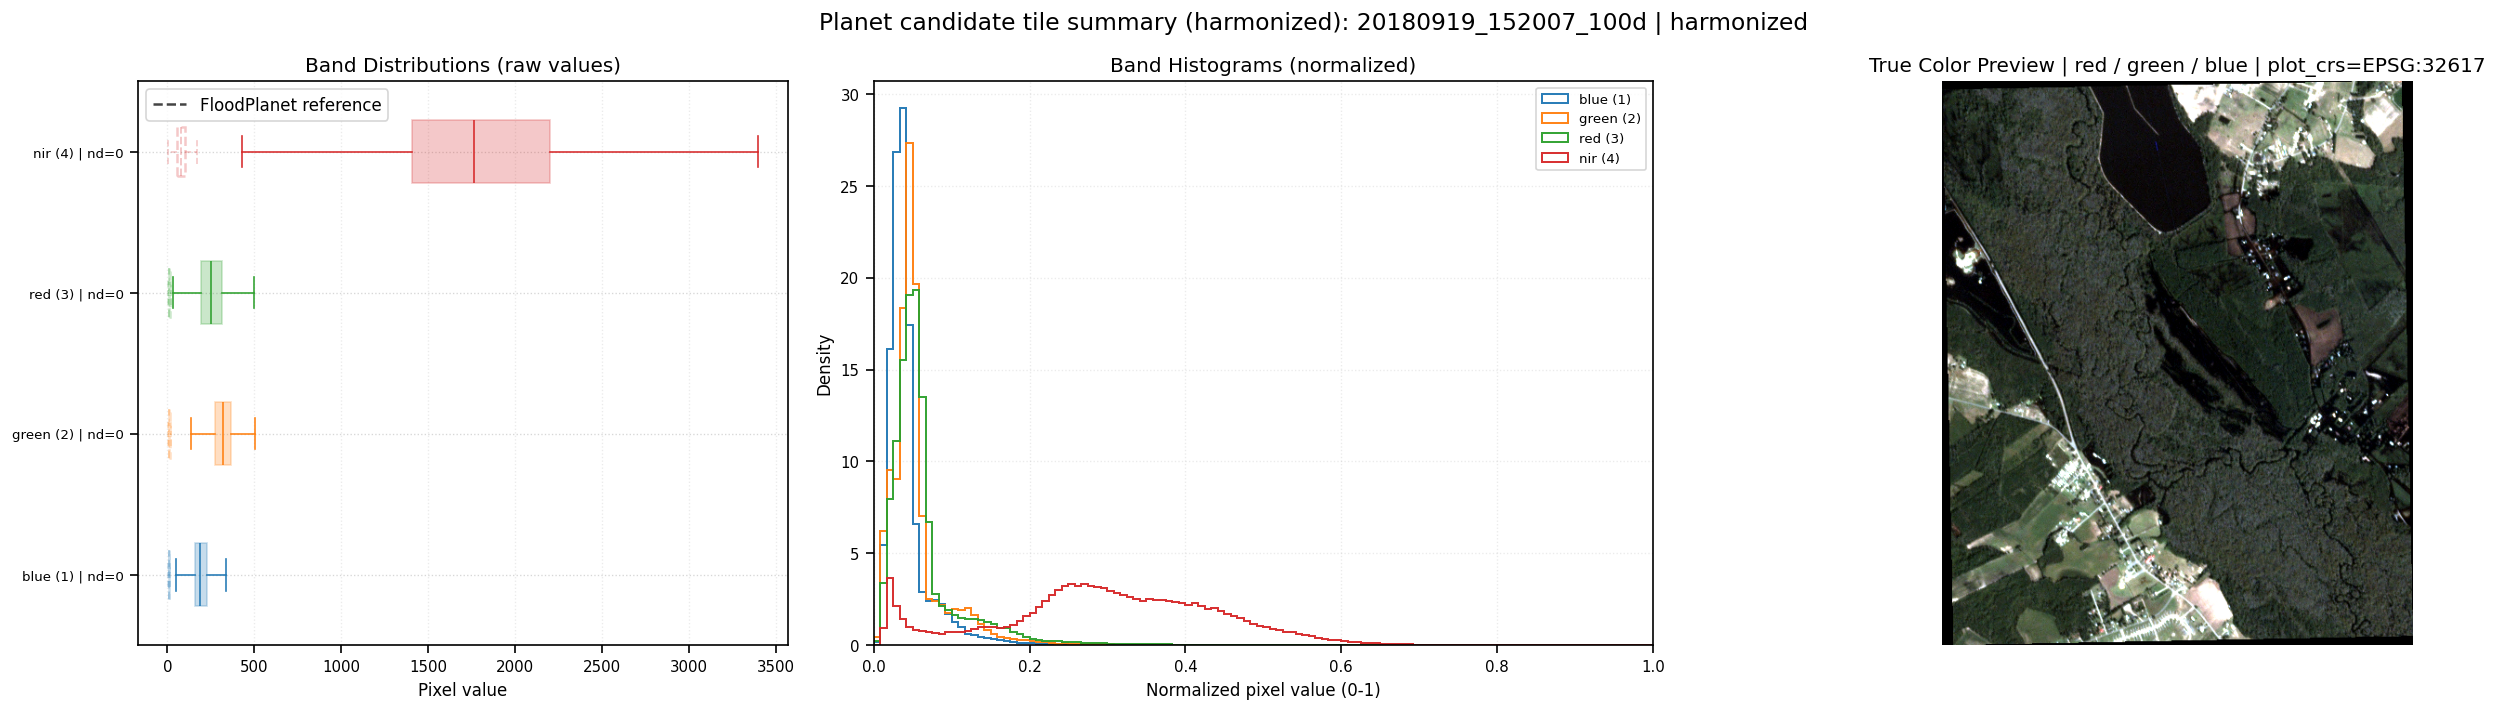

#### harmonized | 3 | 20180920_153030_1004

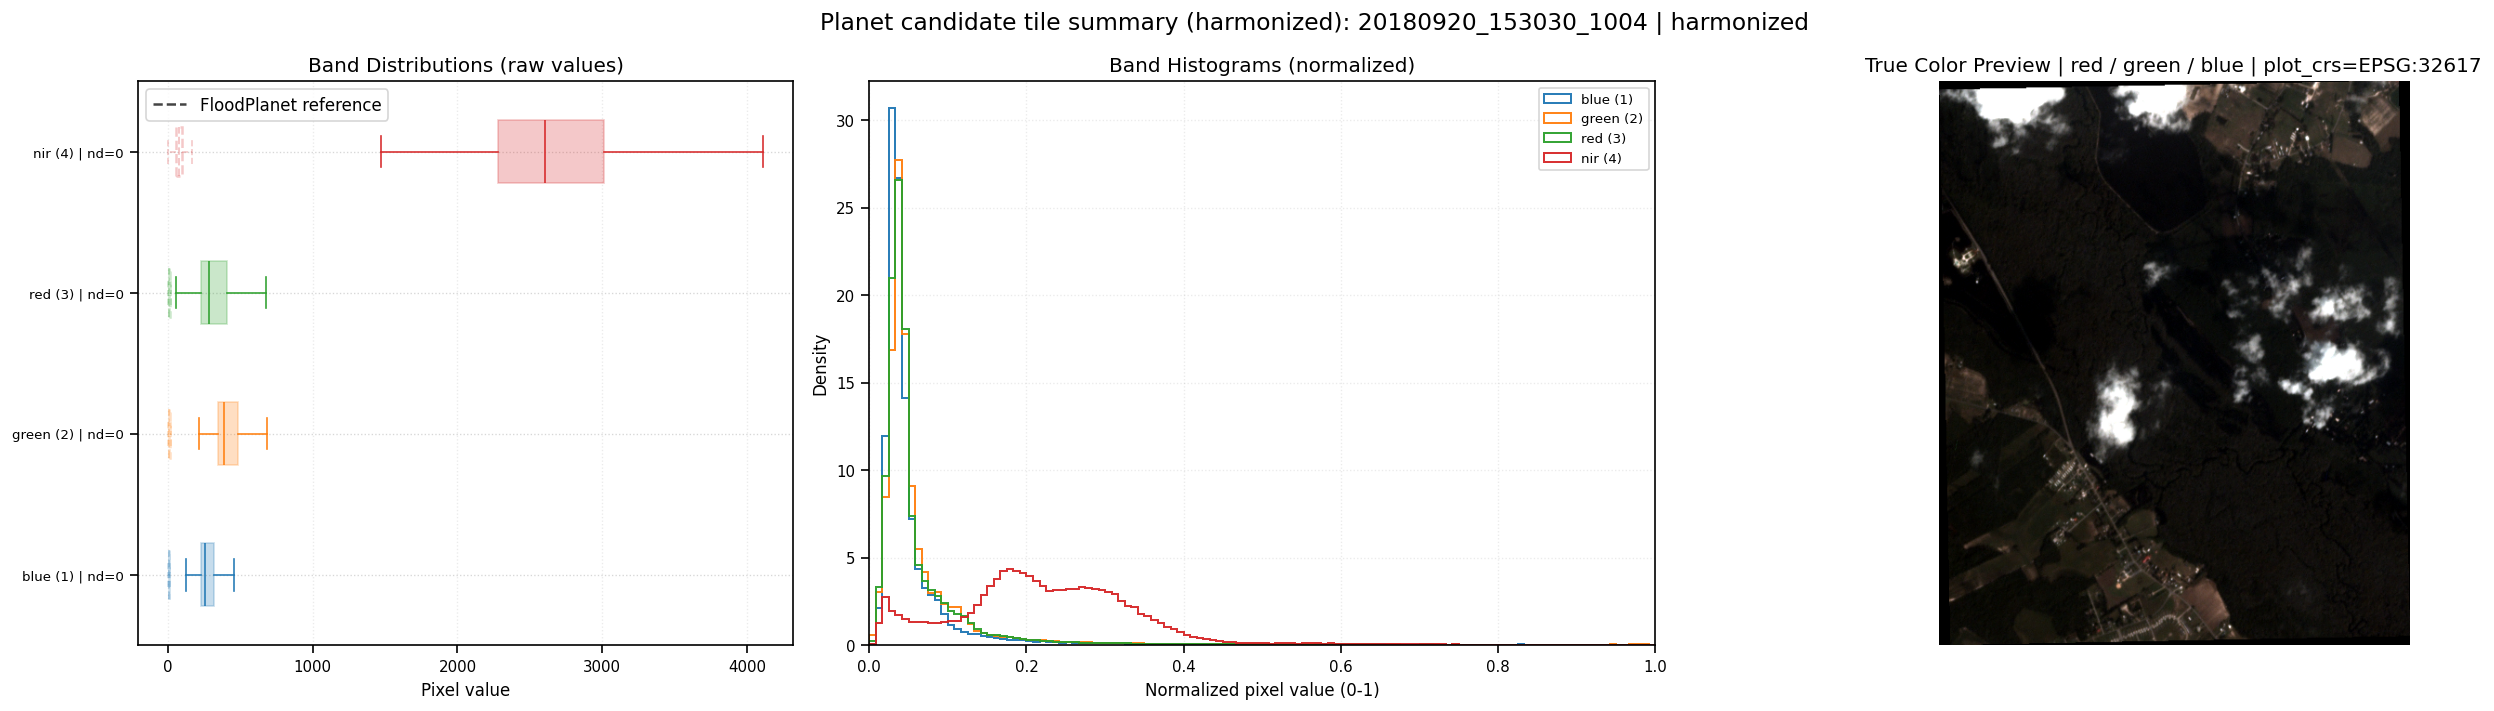

In [10]:
fetch_result_l = []
for mode_d in PLANET_D["mode_l"]:
    fetch_result = await _fetch_selected_items(query_result, use_harmonize=mode_d["use_harmonize"])
    fetch_result_l.append(fetch_result)

fetch_summary_df = pd.DataFrame([
    {
        "mode": fetch_result["mode_label"],
        "status": fetch_result["status"],
        "order_ids": ", ".join(fetch_result["order_ids"]) if fetch_result["order_ids"] else None,
        "download_dir": str(fetch_result["download_dir"].relative_to(REPO_ROOT)),
        "fetched_scene_count": len(fetch_result["fetch_df"]),
    }
    for fetch_result in fetch_result_l
])
fetch_detail_df = pd.concat([fetch_result["fetch_df"] for fetch_result in fetch_result_l], ignore_index=True)

display(Markdown("### 5A. Fetch summary"))
display(fetch_summary_df)

display(Markdown("### 5B. Candidate raster summary"))
display(fetch_detail_df.assign(raster_fp=fetch_detail_df["raster_fp"].map(str)))

for fetch_result in fetch_result_l:
    display(Markdown(f"### 5C. {fetch_result['mode_label'].title()} candidate plots"))
    for _, row in fetch_result["fetch_df"].iterrows():
        display(Markdown(f"#### {fetch_result['mode_label']} | {int(row['fetch_rank'])} | {row['item_id']}"))
        _ = _plot_tile_summary(
            row["raster_fp"],
            tile_label=f"{row['item_id']} | {fetch_result['mode_label']}",
            title_prefix=f"Planet candidate tile summary ({fetch_result['mode_label']})",
            reference_fp=PATH_D["floodplanet_reference_fp"],
        )
